# 01 — Exploratory Data Analysis

Validates segmentation landmarks, visualises signal characteristics for each defect type,
and confirms that the preprocessing pipeline produces physically sensible outputs.

**Approval gate:** confirm all segmentation bounds and signal shapes look correct before proceeding to Step 4 (feature extraction).

## Cell 1 — Imports and setup

In [2]:
import sys
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.signal

# Make src/ modules importable from notebooks/
sys.path.insert(0, os.path.abspath('../src'))

from data_loader import load_file
from preprocessor import resample, detect_pickup_event, segment_journey

%matplotlib inline

# Ensure figures directory exists
os.makedirs('figures', exist_ok=True)

DATA_DIR = '../data/raw/G7'

## Cell 2 — Load and segment: G7 P5 Case71 (Frequency defect)

In [5]:
# Load raw file
df71_raw = load_file(os.path.join(DATA_DIR, 'G7_P5_case71.xls'))

# Resample to 100 Hz (P5 is already ~100 Hz; resample ensures uniform grid)
df71_raw, fs71 = load_file(os.path.join(DATA_DIR, 'G7_P5_case71.xls'))
df71 = resample(df71_raw, fs_original=fs71, fs_target=100)
fs = 100  # Hz

# Detect Arm-2 pickup event (largest peak ~37–39 m/s²)
pickup_time_71 = detect_pickup_event(df71)

# Segment into journey (C1 start → just before pickup) and handoff (18–38 s)
segments_71 = segment_journey(df71, pickup_time_71)
df71_journey = segments_71['journey']
df71_handoff = segments_71['handoff']

print(f'Sampling rate  : {fs} Hz')
print(f'Pickup time    : {pickup_time_71:.2f} s')
print(f'Journey rows   : {len(df71_journey):,}  '
      f'({df71_journey["time"].iloc[0]:.1f}s → {df71_journey["time"].iloc[-1]:.1f}s)')
print(f'Handoff rows   : {len(df71_handoff):,}  '
      f'({df71_handoff["time"].iloc[0]:.1f}s → {df71_handoff["time"].iloc[-1]:.1f}s)')

Sampling rate  : 100 Hz
Pickup time    : 44.99 s
Journey rows   : 3,892  (4.0s → 43.0s)
Handoff rows   : 1,996  (18.0s → 38.0s)


## Cell 3 — Plot 1: Full signal overview (Case71, Frequency defect)

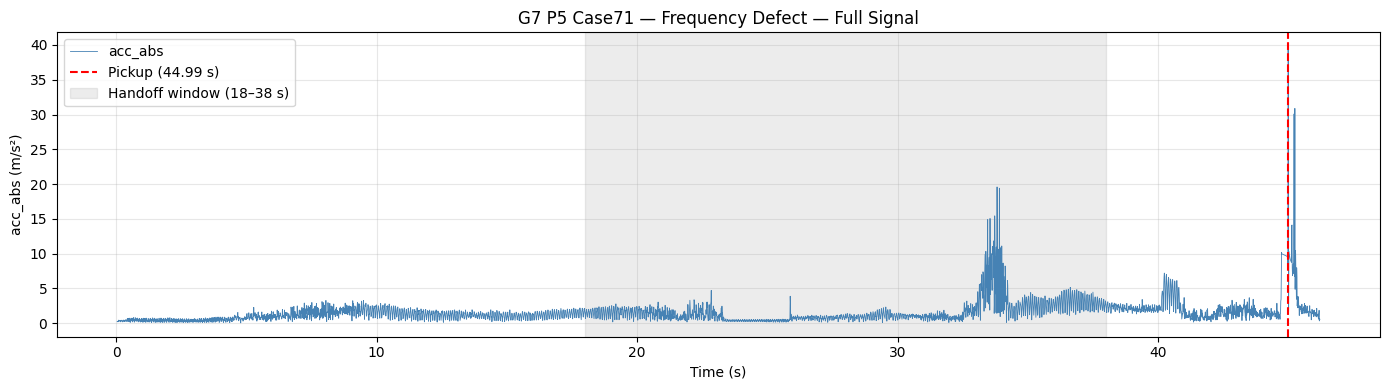

In [6]:
fig, ax = plt.subplots(figsize=(14, 4))

ax.plot(df71['time'], df71['acc_abs'], linewidth=0.6, color='steelblue', label='acc_abs')

# Pickup event — red vertical line
ax.axvline(x=pickup_time_71, color='red', linewidth=1.5, linestyle='--', label=f'Pickup ({pickup_time_71:.2f} s)')

# Handoff window 18–38 s — grey shaded region
ax.axvspan(18, 38, alpha=0.15, color='grey', label='Handoff window (18–38 s)')

ax.set_xlabel('Time (s)')
ax.set_ylabel('acc_abs (m/s²)')
ax.set_title('G7 P5 Case71 — Frequency Defect — Full Signal')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figures/case71_full_signal.png', dpi=150)
plt.show()

## Cell 4 — Plot 2: Handoff zone zoom (Case71, Frequency defect)

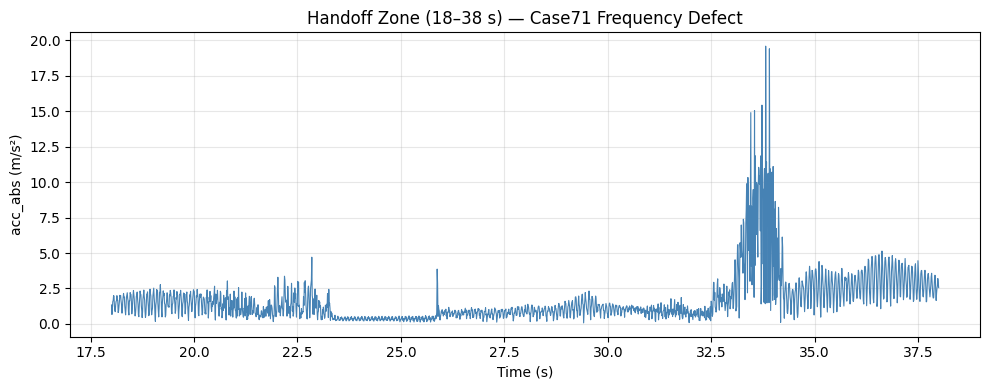

In [7]:
fig, ax = plt.subplots(figsize=(10, 4))

ax.plot(df71_handoff['time'], df71_handoff['acc_abs'], linewidth=0.8, color='steelblue')

ax.set_xlabel('Time (s)')
ax.set_ylabel('acc_abs (m/s²)')
ax.set_title('Handoff Zone (18–38 s) — Case71 Frequency Defect')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figures/case71_handoff_zoom.png', dpi=150)
plt.show()

## Cell 5 — Plot 3: STFT of acc_z on journey segment (Case71, Frequency defect)

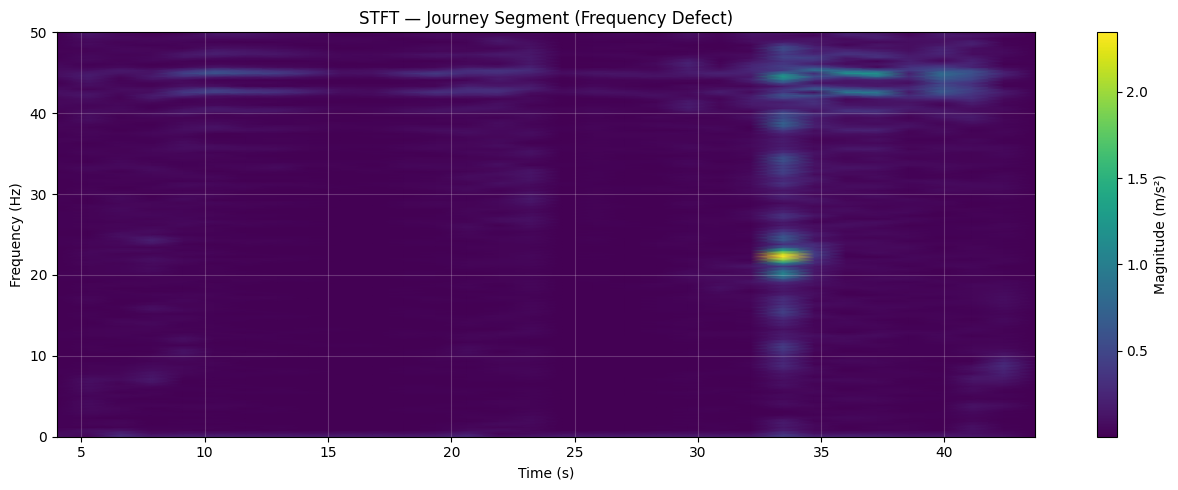

In [ ]:
f_stft, t_stft, Zxx = scipy.signal.stft(
    df71_journey['acc_z'].values,
    fs=fs,
    nperseg=256,
    noverlap=128
)

# Restrict frequency axis to 0–50 Hz
freq_mask = f_stft <= 50

fig, ax = plt.subplots(figsize=(13, 5))

pcm = ax.pcolormesh(
    t_stft + df71_journey['time'].iloc[0],  # shift t to absolute recording time
    f_stft[freq_mask],
    np.abs(Zxx[freq_mask, :]),
    shading='gouraud',
    cmap='viridis'
)

plt.colorbar(pcm, ax=ax, label='Magnitude (m/s²)')

ax.set_ylim(0, 50)
ax.set_xlabel('Time (s)')
ax.set_ylabel('Frequency (Hz)')
ax.set_title('STFT — Journey Segment (Frequency Defect)')
ax.grid(True, alpha=0.2, color='white')

plt.tight_layout()
plt.savefig('figures/case71_stft.png', dpi=150)
plt.show()

---
## Cell 6 — Belt speed case: G7 P5 Case74

> **Expected:** longer recording duration (~71 s) due to slower belt speed (Rail2=30, Rail3=30 vs normal 70/100).
> Pickup event shifts from ~45 s to ~70 s. Journey duration is the primary feature for this defect.

In [11]:
# Load, resample, detect pickup, segment — same pipeline as Case71
df74_raw, fs74 = load_file(os.path.join(DATA_DIR, 'G7_P5_case74.xls'))
df74 = resample(df74_raw, fs_original = fs74, fs_target=100)

pickup_time_74 = detect_pickup_event(df74)
segments_74 = segment_journey(df74, pickup_time_74)
df74_journey = segments_74['journey']
df74_handoff = segments_74['handoff']

print(f'Sampling rate  : {fs} Hz')
print(f'Pickup time    : {pickup_time_74:.2f} s')
print(f'Journey rows   : {len(df74_journey):,}  '
      f'({df74_journey["time"].iloc[0]:.1f}s → {df74_journey["time"].iloc[-1]:.1f}s)')
print(f'Handoff rows   : {len(df74_handoff):,}  '
      f'({df74_handoff["time"].iloc[0]:.1f}s → {df74_handoff["time"].iloc[-1]:.1f}s)')

Sampling rate  : 100 Hz
Pickup time    : 69.62 s
Journey rows   : 6,345  (4.0s → 67.6s)
Handoff rows   : 1,998  (18.0s → 38.0s)


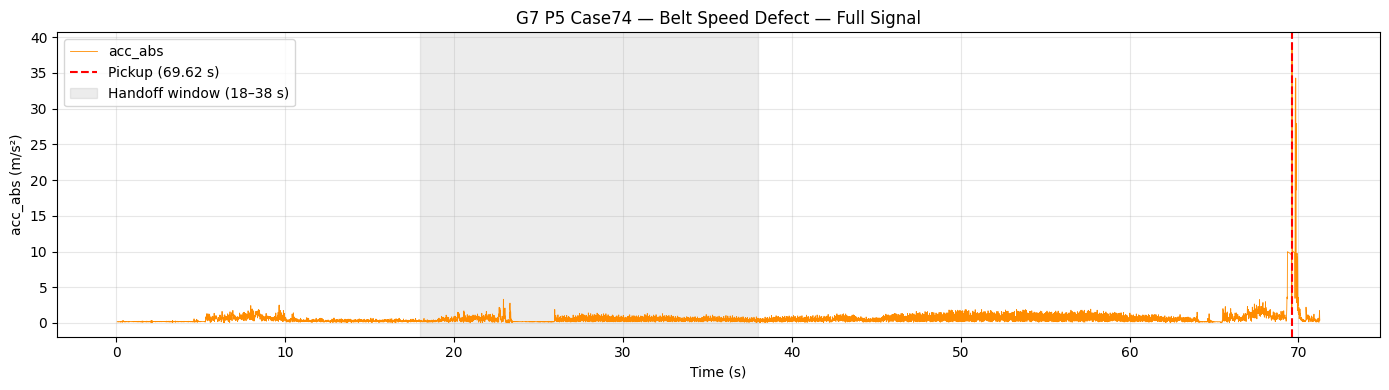

In [12]:
fig, ax = plt.subplots(figsize=(14, 4))

ax.plot(df74['time'], df74['acc_abs'], linewidth=0.6, color='darkorange', label='acc_abs')
ax.axvline(x=pickup_time_74, color='red', linewidth=1.5, linestyle='--', label=f'Pickup ({pickup_time_74:.2f} s)')
ax.axvspan(18, 38, alpha=0.15, color='grey', label='Handoff window (18–38 s)')

ax.set_xlabel('Time (s)')
ax.set_ylabel('acc_abs (m/s²)')
ax.set_title('G7 P5 Case74 — Belt Speed Defect — Full Signal')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figures/case74_full_signal.png', dpi=150)
plt.show()

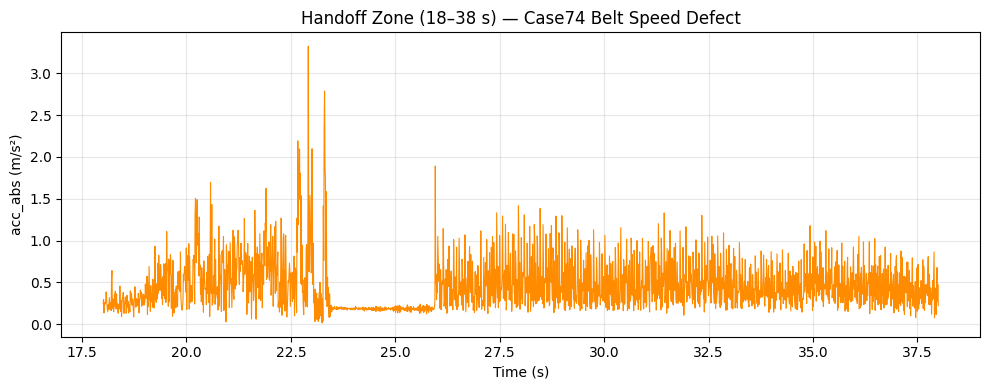

In [13]:
fig, ax = plt.subplots(figsize=(10, 4))

ax.plot(df74_handoff['time'], df74_handoff['acc_abs'], linewidth=0.8, color='darkorange')

ax.set_xlabel('Time (s)')
ax.set_ylabel('acc_abs (m/s²)')
ax.set_title('Handoff Zone (18–38 s) — Case74 Belt Speed Defect')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figures/case74_handoff_zoom.png', dpi=150)
plt.show()

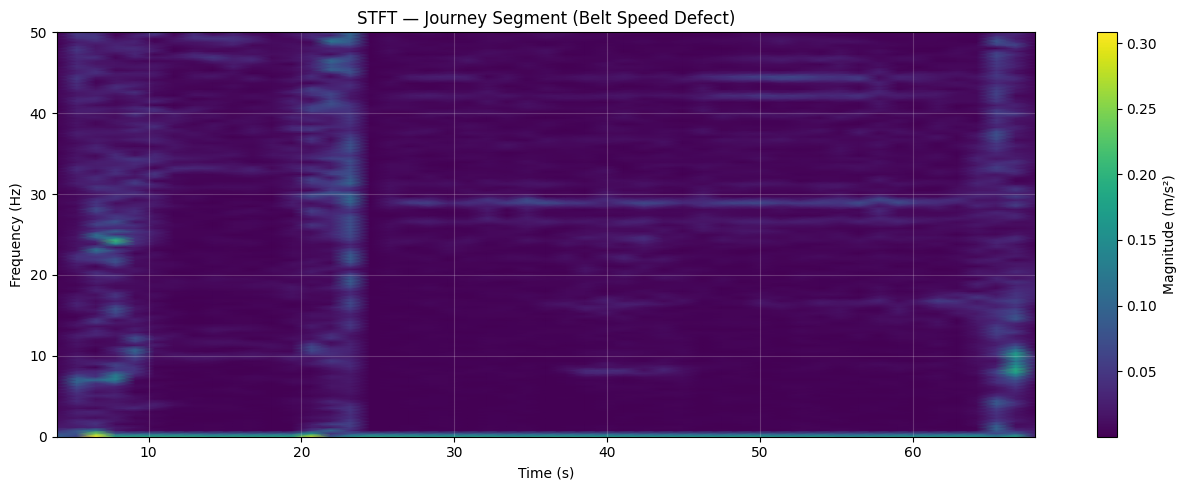

In [14]:
f_stft74, t_stft74, Zxx74 = scipy.signal.stft(
    df74_journey['acc_z'].values,
    fs=fs,
    nperseg=256,
    noverlap=128
)

freq_mask74 = f_stft74 <= 50

fig, ax = plt.subplots(figsize=(13, 5))

pcm = ax.pcolormesh(
    t_stft74 + df74_journey['time'].iloc[0],
    f_stft74[freq_mask74],
    np.abs(Zxx74[freq_mask74, :]),
    shading='gouraud',
    cmap='viridis'
)
plt.colorbar(pcm, ax=ax, label='Magnitude (m/s²)')

ax.set_ylim(0, 50)
ax.set_xlabel('Time (s)')
ax.set_ylabel('Frequency (Hz)')
ax.set_title('STFT — Journey Segment (Belt Speed Defect)')
ax.grid(True, alpha=0.2, color='white')

plt.tight_layout()
plt.savefig('figures/case74_stft.png', dpi=150)
plt.show()

---
## Cell 7 — Inclination case: G7 P5 Case72

Cells 2–4 repeated for the inclination defect. No STFT — the relevant feature is the
transient impact signature in the **handoff zone**, not a sustained frequency component.

Compare handoff zone peak magnitude below vs Case71 (frequency defect) to confirm
the inclination transient is visually distinct.

In [17]:
df72_raw, fs75 = load_file(os.path.join(DATA_DIR, 'G7_P5_case72.xls'))
df72 = resample(df72_raw, fs_original=fs75, fs_target=100)

pickup_time_72 = detect_pickup_event(df72)
segments_72 = segment_journey(df72, pickup_time_72)
df72_journey = segments_72['journey']
df72_handoff = segments_72['handoff']

print(f'Sampling rate  : {fs} Hz')
print(f'Pickup time    : {pickup_time_72:.2f} s')
print(f'Journey rows   : {len(df72_journey):,}  '
      f'({df72_journey["time"].iloc[0]:.1f}s → {df72_journey["time"].iloc[-1]:.1f}s)')
print(f'Handoff rows   : {len(df72_handoff):,}  '
      f'({df72_handoff["time"].iloc[0]:.1f}s → {df72_handoff["time"].iloc[-1]:.1f}s)')

Sampling rate  : 100 Hz
Pickup time    : 45.06 s
Journey rows   : 3,901  (4.0s → 43.1s)
Handoff rows   : 1,997  (18.0s → 38.0s)


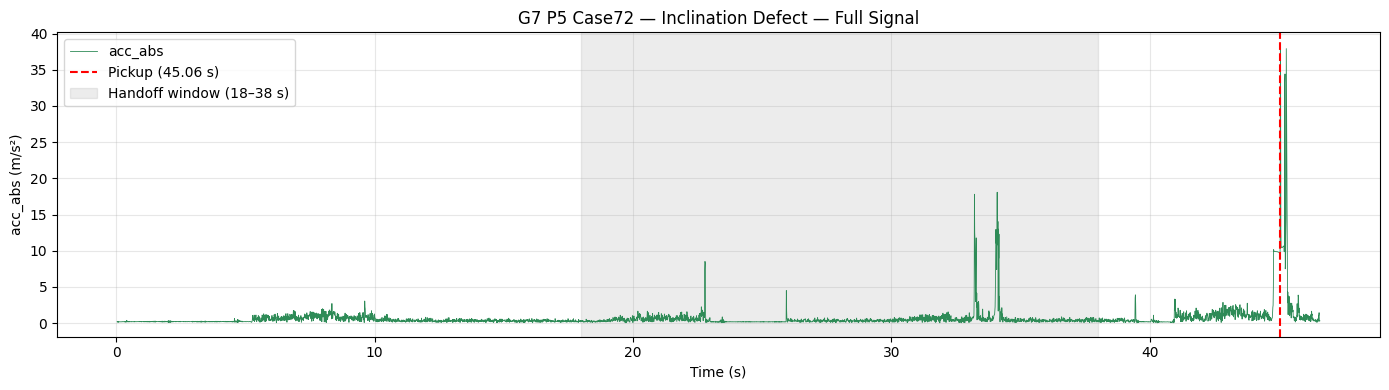

In [18]:
fig, ax = plt.subplots(figsize=(14, 4))

ax.plot(df72['time'], df72['acc_abs'], linewidth=0.6, color='seagreen', label='acc_abs')
ax.axvline(x=pickup_time_72, color='red', linewidth=1.5, linestyle='--', label=f'Pickup ({pickup_time_72:.2f} s)')
ax.axvspan(18, 38, alpha=0.15, color='grey', label='Handoff window (18–38 s)')

ax.set_xlabel('Time (s)')
ax.set_ylabel('acc_abs (m/s²)')
ax.set_title('G7 P5 Case72 — Inclination Defect — Full Signal')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figures/case72_full_signal.png', dpi=150)
plt.show()

Handoff peak — Case71 (Frequency)   : 19.586 m/s²
Handoff peak — Case72 (Inclination) : 18.076 m/s²


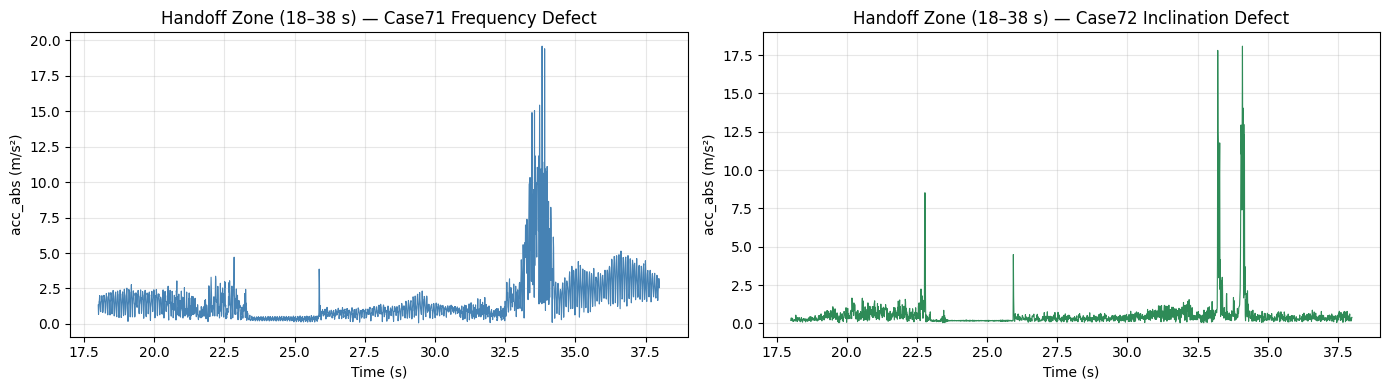

In [19]:
# Side-by-side comparison: inclination handoff (Case72) vs frequency handoff (Case71)
fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=False)

axes[0].plot(df71_handoff['time'], df71_handoff['acc_abs'], linewidth=0.8, color='steelblue')
axes[0].set_title('Handoff Zone (18–38 s) — Case71 Frequency Defect')
axes[0].set_xlabel('Time (s)')
axes[0].set_ylabel('acc_abs (m/s²)')
axes[0].grid(True, alpha=0.3)

axes[1].plot(df72_handoff['time'], df72_handoff['acc_abs'], linewidth=0.8, color='seagreen')
axes[1].set_title('Handoff Zone (18–38 s) — Case72 Inclination Defect')
axes[1].set_xlabel('Time (s)')
axes[1].set_ylabel('acc_abs (m/s²)')
axes[1].grid(True, alpha=0.3)

# Print peak magnitudes for direct comparison
peak71 = df71_handoff['acc_abs'].max()
peak72 = df72_handoff['acc_abs'].max()
print(f'Handoff peak — Case71 (Frequency)   : {peak71:.3f} m/s²')
print(f'Handoff peak — Case72 (Inclination) : {peak72:.3f} m/s²')

plt.tight_layout()
plt.savefig('figures/case72_handoff_comparison.png', dpi=150)
plt.show()

---
## Cell 8 — Damping case: Fixed phone (P1) vs Moving phone (P5)

Fixed phones operate in a completely different amplitude world (~0.07 m/s² mean vs P5 ~0.64 m/s²).
Twin y-axes are required — never plot both on the same axis without normalisation.

P1 rows after resample : 4,671  (t: 0.02s → 46.72s)
P5 rows after resample : 4,648  (t: 0.01s → 46.56s)
P1 acc_abs mean / max  : 0.0775 / 0.7230 m/s²
P5 acc_abs mean / max  : 0.6410 / 37.6016 m/s²


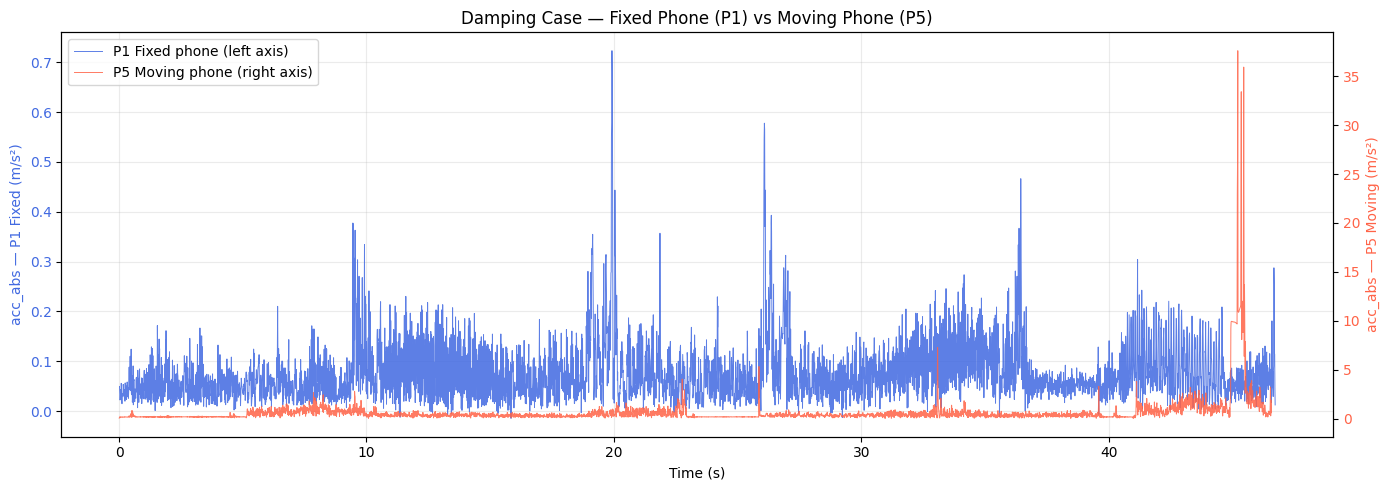

In [22]:
# G7 P1 case73 — fixed phone, needs resampling to 100 Hz (recorded at ~398 Hz on IV2201)
df73_p1_raw, fs73_p1 = load_file(os.path.join(DATA_DIR, 'G7_P1_case73.xls'))
df73_p1 = resample(df73_p1_raw, fs_original=fs73_p1, fs_target=100)

# G7 P5 case73 — moving phone, already ~100 Hz
df73_p5_raw, fs73_p5 = load_file(os.path.join(DATA_DIR, 'G7_P5_case73.xls'))
df73_p5 = resample(df73_p5_raw, fs_original=fs73_p5, fs_target=100)

print(f'P1 rows after resample : {len(df73_p1):,}  '
      f'(t: {df73_p1["time"].iloc[0]:.2f}s → {df73_p1["time"].iloc[-1]:.2f}s)')
print(f'P5 rows after resample : {len(df73_p5):,}  '
      f'(t: {df73_p5["time"].iloc[0]:.2f}s → {df73_p5["time"].iloc[-1]:.2f}s)')
print(f'P1 acc_abs mean / max  : {df73_p1["acc_abs"].mean():.4f} / {df73_p1["acc_abs"].max():.4f} m/s²')
print(f'P5 acc_abs mean / max  : {df73_p5["acc_abs"].mean():.4f} / {df73_p5["acc_abs"].max():.4f} m/s²')

fig, ax1 = plt.subplots(figsize=(14, 5))
ax2 = ax1.twinx()

line1, = ax1.plot(
    df73_p1['time'], df73_p1['acc_abs'],
    color='royalblue', linewidth=0.7, alpha=0.85,
    label='P1 Fixed phone (left axis)'
)
line2, = ax2.plot(
    df73_p5['time'], df73_p5['acc_abs'],
    color='tomato', linewidth=0.7, alpha=0.85,
    label='P5 Moving phone (right axis)'
)

ax1.set_xlabel('Time (s)')
ax1.set_ylabel('acc_abs — P1 Fixed (m/s²)', color='royalblue')
ax2.set_ylabel('acc_abs — P5 Moving (m/s²)', color='tomato')
ax1.tick_params(axis='y', labelcolor='royalblue')
ax2.tick_params(axis='y', labelcolor='tomato')

ax1.set_title('Damping Case — Fixed Phone (P1) vs Moving Phone (P5)')
ax1.grid(True, alpha=0.25)

lines = [line1, line2]
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper left')

plt.tight_layout()
plt.savefig('figures/case73_damping_p1_vs_p5.png', dpi=150)
plt.show()

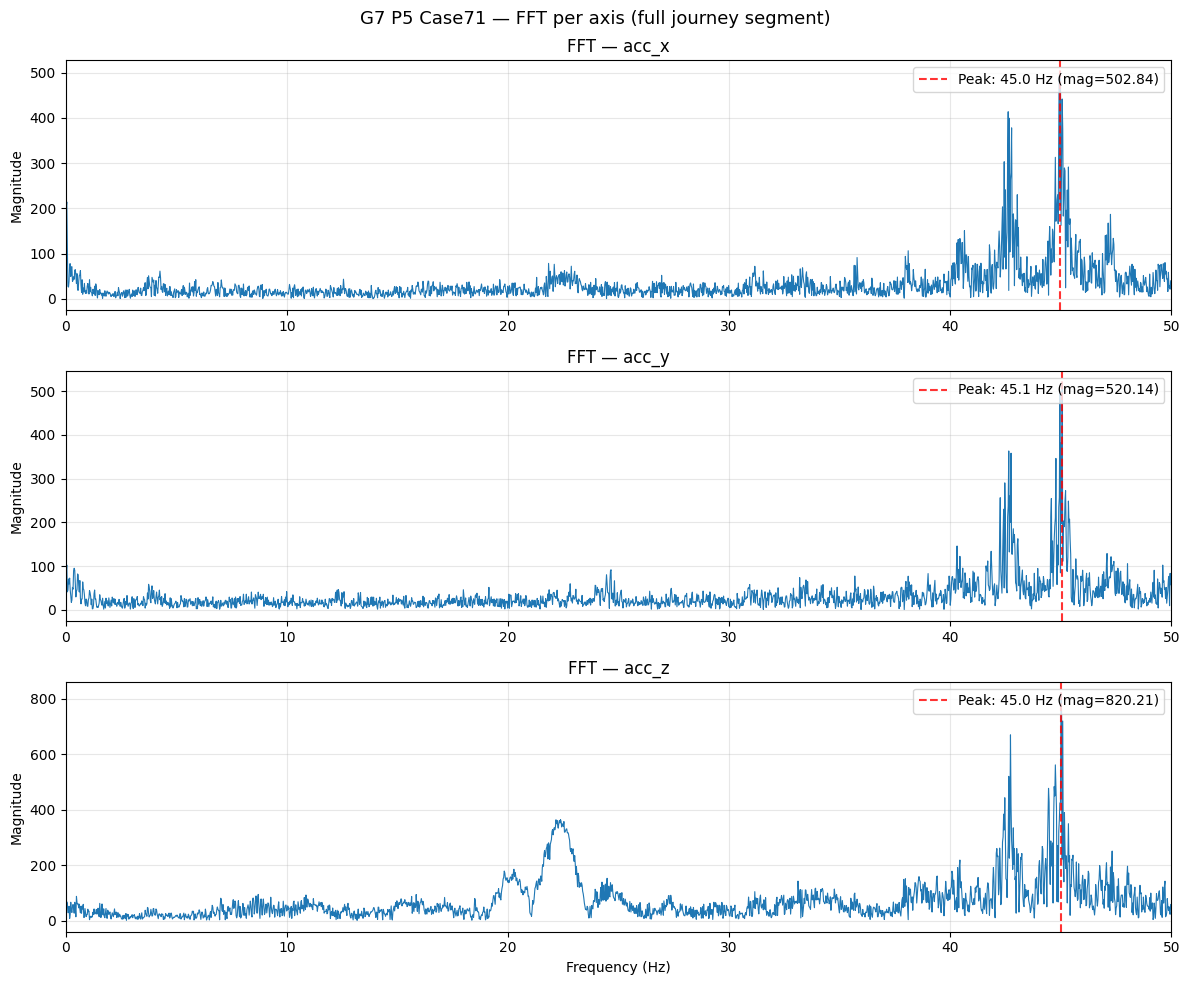

In [24]:
from scipy.fft import fft, fftfreq
import numpy as np
import os

fig, axes = plt.subplots(3, 1, figsize=(12, 10))
axes_labels = ['acc_x', 'acc_y', 'acc_z']

for ax, col in zip(axes, axes_labels):
    signal = df71_journey[col].values
    N = len(signal)
    yf = np.abs(fft(signal))[:N//2]
    xf = fftfreq(N, d=1/100)[:N//2]
    
    # Ignore DC component (0 Hz)
    mask = xf > 2
    peak_freq = xf[mask][np.argmax(yf[mask])]
    peak_mag = yf[mask].max()
    
    ax.plot(xf, yf, linewidth=0.8)
    ax.axvline(peak_freq, color='red', linestyle='--', alpha=0.8,
               label=f'Peak: {peak_freq:.1f} Hz (mag={peak_mag:.2f})')
    ax.set_xlim(0, 50)
    ax.set_ylabel('Magnitude')
    ax.set_title(f'FFT — {col}')
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('Frequency (Hz)')
plt.suptitle('G7 P5 Case71 — FFT per axis (full journey segment)', fontsize=13)
plt.tight_layout()
plt.savefig('figures/fft_per_axis_case71.png', dpi=150)
plt.show()

---
## Cell 9 — Key observations (fill in after running)

Confirm the following before proceeding to Step 4 (feature extraction).

### Segmentation landmarks

- [ ] **Case71 pickup time** detected at: _____ s (expected ~44.99 s)
- [ ] **Case71 journey segment**: _____ → _____ s (expected 4.0 → 43.0 s, ~3892 rows)
- [ ] **Case74 pickup time** detected at: _____ s (expected ~70 s — slow belt)
- [ ] **Case74 journey duration** noticeably longer than Case71: _____ s vs _____ s

### Frequency defect (Case71)

- [ ] Full signal shows sustained oscillation during the journey segment: _____
- [ ] STFT shows a horizontal energy band at approximately _____ Hz
- [ ] Pickup event peak clearly the largest feature in the signal: _____

### Belt speed defect (Case74)

- [ ] Recording duration approximately _____ s (expected ~71 s vs ~46 s normal)
- [ ] STFT shows low-frequency differences vs Case71: _____

### Inclination defect (Case72)

- [ ] Handoff zone peak magnitude: _____ m/s² vs Case71 handoff peak: _____ m/s²
- [ ] Inclination transient is visually distinct from frequency-only signal in handoff zone: _____
- [ ] Impact transient timing within 18–38 s window: _____ s

### Damping — amplitude scale separation (Case73)

- [ ] P1 mean acc_abs: _____ m/s² (expected ~0.07 m/s²)
- [ ] P5 mean acc_abs: _____ m/s² (expected ~0.64 m/s²)
- [ ] Amplitude ratio P5/P1 ≈ _____× — confirms twin y-axes are mandatory
- [ ] P1 fixed phone signal shows structural vibration pattern different from P5 journey dynamics: _____

### Go / No-go

> All boxes checked → proceed to Step 4: `src/features/`
>
> Any box unchecked → investigate in preprocessor.py before continuing